# IT3051 – Fundamentals of Data Mining | Mini Project 2026
## Stage 4 – Data Preprocessing & Feature Engineering
**Group:** Mine4Data (DS.Y3S2.01.01) · **Project:** Airbnb Listing Price Prediction · **Input:** `Airbnb_Data.csv` · **Builds on:** `01_EDA_Airbnb.ipynb`

This notebook turns the raw data into model-ready features. Every decision is traced back to an EDA finding (EDA §x).

### Design: two layers, to make data leakage impossible by construction
| Layer | Where | What | Learns from data? | When it runs |
|---|---|---|---|---|
| **1. Rules** | `clean_and_engineer()` in [src/preprocessing.py](src/preprocessing.py) | Type fixes, invalid → missing, rule-based features (ratios, durations, amenity parsing) | **No** – only fixed constants (snapshot date, city-centre coordinates, synonym map) | Before the split, and identically on a single listing in the backend |
| **2. Learned steps** | `build_preprocessor()` sklearn `Pipeline` | Location imputation, median/mode imputation, rare-level grouping, amenity vocabulary, target encoding, winsorising, scaling, correlation filter | **Yes** | `fit` on the **training split only**; refitted inside every CV fold |

Putting the code in a `.py` module (not only in this notebook) means the **Stage 9 backend imports the exact same preprocessing**, which is a technical requirement of the brief.

| # | Section | Stage 4 checklist item |
|---|---|---|
| 1 | Setup | – |
| 2 | Columns removed | feature selection (a-priori) |
| 3 | Invalid & duplicate records | handle duplicate / invalid records |
| 4 | Rule-based cleaning & feature engineering | feature engineering |
| 5 | Train / test split | separate training and testing data |
| 6 | Evidence for engineered features (train only) | feature engineering |
| 7 | Missing values | handle missing values |
| 8 | Outliers | treat outliers where justified |
| 9 | Encoding categorical variables | encode categorical variables |
| 10 | Scaling | scale / normalise |
| 11 | Fitting the full pipelines | – |
| 12 | Feature selection | feature selection |
| 13 | Leakage prevention (with a demonstration) | avoid information leakage |
| 14 | End-to-end sanity check (train CV only) | – |
| 15 | Saving artefacts for Stage 6 | – |
| 16 | Summary of preprocessing decisions | justify each decision |

## 1. Setup

In [1]:
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder

from src import preprocessing as pp

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", "{:,.3f}".format)

FIG_DIR, DATA_DIR, MODEL_DIR = Path("figures/preprocessing"), Path("data/processed"), Path("models")
for d in (FIG_DIR, DATA_DIR, MODEL_DIR):
    d.mkdir(parents=True, exist_ok=True)

SURFACE, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df"
BLUE, BLUE_LIGHT, ORANGE, AQUA, RED = "#2a78d6", "#86b6ef", "#eb6834", "#1baf7a", "#e34948"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": "#c9c8c3", "axes.labelcolor": INK2, "text.color": INK,
    "axes.titlecolor": INK, "axes.titlesize": 11.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "xtick.color": INK2, "ytick.color": INK2, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 2, "font.size": 10, "legend.frameon": False,
    "axes.prop_cycle": plt.cycler(color=[BLUE, ORANGE, AQUA, "#eda100", "#e87ba4", "#008300", "#4a3aa7", RED]),
})

def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", dpi=130, bbox_inches="tight")
    plt.show()

RANDOM_STATE = pp.RANDOM_STATE
raw = pd.read_csv("Airbnb_Data.csv")
print(f"Raw data: {raw.shape[0]:,} rows × {raw.shape[1]} columns")

Raw data: 74,111 rows × 29 columns


## 2. Columns removed before modelling

In [2]:
used_raw = ["log_price", "property_type", "room_type", "amenities", "accommodates", "bathrooms", "bed_type",
            "cancellation_policy", "cleaning_fee", "city", "first_review", "host_identity_verified",
            "host_response_rate", "host_since", "instant_bookable", "last_review", "latitude", "longitude",
            "neighbourhood", "number_of_reviews", "review_scores_rating", "bedrooms", "beds"]
removed = pd.DataFrame([
    ("id", "Unique identifier – no predictive meaning (ρ with price ≈ 0, EDA §16)"),
    ("name", "Free text; weak signal (ρ ≈ 0.06) that mostly restates room type/size (EDA §14)"),
    ("description", "Free text truncated at 1,000 chars; weak signal; could leak the price as text (EDA §14, §16)"),
    ("thumbnail_url", "Image URL; missingness is a scraping artefact, meaningless for a new host (EDA §14)"),
    ("zipcode", "Dirty (769 raw → 649 real codes, 8 contradict city) and redundant with neighbourhood + lat/lon (EDA §5)"),
    ("host_has_profile_pic", "99.7% True – near-zero variance, η² ≈ 0 (EDA §8); confirmed in §12 below"),
], columns=["column", "reason"]).set_index("column")
assert set(used_raw) | set(removed.index) == set(raw.columns)
display(removed)
print(f"{len(used_raw) - 1} raw columns are used as inputs (+ the target log_price).")

,reason
column,
id,Unique identifier – no predictive meaning (ρ w...
name,Free text; weak signal (ρ ≈ 0.06) that mostly ...
description,"Free text truncated at 1,000 chars; weak signa..."
thumbnail_url,"Image URL; missingness is a scraping artefact,..."
zipcode,"Dirty (769 raw → 649 real codes, 8 contradict ..."
host_has_profile_pic,"99.7% True – near-zero variance, η² ≈ 0 (EDA §..."


22 raw columns are used as inputs (+ the target log_price).


Everything else is kept and transformed. Removing these columns *before* modelling is **a-priori feature selection** backed by EDA evidence. Data-driven selection follows in §12.

## 3. Invalid & duplicate records

In [3]:
print(f"Exact duplicate rows: {raw.duplicated().sum()} | duplicate ids: {raw['id'].duplicated().sum()}")

valid, invalid = pp.remove_invalid_rows(raw)
print(f"Removed {len(invalid)} rows with price < ${pp.MIN_VALID_PRICE:.0f} → {len(valid):,} rows remain")
display(invalid.assign(price=np.exp(invalid["log_price"]))[["id", "price", "city", "room_type", "property_type", "accommodates"]])

print("Invalid values converted to missing (imputed later, see §7):")
print(f"  bathrooms == 0 : {(valid['bathrooms'] == 0).sum()} rows")
print(f"  beds == 0      : {(valid['beds'] == 0).sum()} rows")

Exact duplicate rows: 0 | duplicate ids: 0
Removed 2 rows with price < $10 → 74,109 rows remain


,id,price,city,room_type,property_type,accommodates
3898,4822822,5.000,NYC,Entire home/apt,Apartment,2
11632,17972519,1.000,NYC,Shared room,Condominium,1


Invalid values converted to missing (imputed later, see §7):
  bathrooms == 0 : 198 rows
  beds == 0      : 4 rows


**Decisions & justification**
- **Duplicates:** none exist (EDA §4), so no rows are removed.
- **Invalid prices:** the **$1 and $5** listings are data-entry errors (EDA §5). Their `log_price` values (0.0 and 1.6) sit 4–6 standard deviations below the mean, where they would pull the linear models. This removal is a **fixed domain rule** (price < $10), not a statistic learned from the data. So it is safe to apply before the split, and it also keeps impossible labels out of the test set.
- **Invalid feature values:** 0 bathrooms and 0 beds are physically implausible for a rentable listing, so they are set to **missing** and imputed. We don't delete these rows, because the rest of each row is valid.
- **Kept on purpose:** `bedrooms = 0` means a studio (valid, flagged as `is_studio`); `beds > accommodates` is unusual but possible; very large listings are genuine (EDA §7).

## 4. Rule-based cleaning & feature engineering (Layer 1)

In [4]:
X_all = pp.clean_and_engineer(valid)
y_all = valid[pp.TARGET]
print(f"Engineered frame: {X_all.shape[0]:,} rows × {X_all.shape[1]} columns")
X_all.head(3)

Engineered frame: 74,109 rows × 34 columns


,city,room_type,property_type,bed_type,neighbourhood,accommodates,bathrooms,bedrooms,beds,latitude,longitude,number_of_reviews,review_scores_rating,host_response_rate,cleaning_fee,instant_bookable,host_identity_verified,host_has_profile_pic,cancellation_ordinal,is_real_bed,is_studio,guests_per_bedroom,beds_per_guest,guests_per_bathroom,amenity_list,amenity_count,amenities_empty,host_tenure_yrs,listing_age_yrs,days_since_last_review,has_reviews,log_number_of_reviews,review_score_missing,response_rate_missing
0,NYC,Entire home/apt,Apartment,Real Bed,NYC | Brooklyn Heights,3,1.000,1.000,1.000,40.697,-73.992,2,100.000,NaN,1.000,0.000,1.000,1.000,2.000,1.000,0.000,3.000,0.333,3.000,"[Air conditioning, Essentials, Family/kid frie...",8.000,0.000,5.528,1.298,444.000,1.000,1.099,0.000,1.000
1,NYC,Entire home/apt,Apartment,Real Bed,NYC | Hell's Kitchen,7,1.000,3.000,3.000,40.766,-73.989,6,93.000,100.000,1.000,1.000,0.000,1.000,2.000,1.000,0.000,2.333,0.429,7.000,"[Air conditioning, Dryer, Essentials, Family/k...",14.000,0.000,0.296,0.167,12.000,1.000,1.946,0.000,0.000
2,NYC,Entire home/apt,Apartment,Real Bed,NYC | Harlem,5,1.000,1.000,3.000,40.808,-73.944,10,92.000,100.000,1.000,1.000,1.000,1.000,1.000,1.000,0.000,5.000,0.600,5.000,"[Air conditioning, Breakfast, Buzzer/wireless ...",18.000,0.000,0.945,0.433,21.000,1.000,2.398,0.000,0.000


In [5]:
engineered = pd.DataFrame([
    ("neighbourhood", "city + ' | ' + neighbourhood", "19 names exist in several cities (EDA §8)"),
    ("guests_per_bedroom", "accommodates / max(bedrooms, 1)", "Separates crowding from size; reduces size collinearity (EDA §10)"),
    ("beds_per_guest", "beds / accommodates", "Exposes inconsistent capacity (beds > guests, EDA §5)"),
    ("guests_per_bathroom", "accommodates / bathrooms", "Comfort / luxury proxy"),
    ("is_studio", "bedrooms == 0", "6,715 studios are valid, not missing (EDA §5)"),
    ("dist_centre_km", "haversine(lat/lon, fixed city centre) *", "Raw lat/lon ρ ≈ 0, distance ρ = −0.27 (EDA §11)"),
    ("amenity_list", "parse string, drop junk, merge synonyms", "130 raw tokens with junk + synonyms (EDA §12)"),
    ("amenity_count", "len(amenity_list)", "ρ = 0.21 with price (EDA §12)"),
    ("amenities_empty", "amenity_count == 0", "586 empty sets (EDA §5) – later removed by the variance filter (§12)"),
    ("cancellation_ordinal", "flexible=0, moderate=1, strict/super_strict=2", "Ordinal, monotonic with price; super_strict only 0.2% (EDA §8–9)"),
    ("is_real_bed", "bed_type == 'Real Bed'", "97% Real Bed; 5 levels → 1 flag (EDA §8)"),
    ("host_tenure_yrs", "(2017-10-05 − host_since) in years", "Dates must be numeric (EDA §13)"),
    ("listing_age_yrs", "(2017-10-05 − first_review) in years", "History feature (EDA §13, §16)"),
    ("days_since_last_review", "(2017-10-05 − last_review) in days", "History feature (EDA §13, §16)"),
    ("log_number_of_reviews", "log1p(number_of_reviews)", "Skew 3.7 (EDA §7)"),
    ("has_reviews", "number_of_reviews > 0", "Review fields missing = never reviewed (EDA §3)"),
    ("review_score_missing", "review_scores_rating is NaN", "Missingness predicts price (EDA §3)"),
    ("response_rate_missing", "host_response_rate is NaN", "Missingness predicts price (EDA §3)"),
    ("host_response_rate", "'95%' → 95.0", "Stored as text (EDA §2)"),
    ("cleaning_fee, instant_bookable, host_identity_verified", "'t'/'f' → 1/0", "Stored as text (EDA §2)"),
], columns=["feature", "rule", "why (EDA evidence)"]).set_index("feature")
engineered

,rule,why (EDA evidence)
feature,,
neighbourhood,city + ' | ' + neighbourhood,19 names exist in several cities (EDA §8)
guests_per_bedroom,"accommodates / max(bedrooms, 1)",Separates crowding from size; reduces size col...
beds_per_guest,beds / accommodates,"Exposes inconsistent capacity (beds > guests, ..."
guests_per_bathroom,accommodates / bathrooms,Comfort / luxury proxy
is_studio,bedrooms == 0,"6,715 studios are valid, not missing (EDA §5)"
dist_centre_km,"haversine(lat/lon, fixed city centre) *","Raw lat/lon ρ ≈ 0, distance ρ = −0.27 (EDA §11)"
amenity_list,"parse string, drop junk, merge synonyms",130 raw tokens with junk + synonyms (EDA §12)
amenity_count,len(amenity_list),ρ = 0.21 with price (EDA §12)
amenities_empty,amenity_count == 0,586 empty sets (EDA §5) – later removed by the...


\* `dist_centre_km` is computed inside the pipeline's `LocationImputer`. Latitude/longitude can be missing at prediction time: the web form may only give a neighbourhood, and the imputer then fills the coordinates first.

**Why these steps are leakage-free:** each engineered value depends only on **the same row** plus fixed constants. The snapshot date (2017-10-05) is the dataset's collection date, and the city centres are public landmarks. Running this before or after the split gives *identical* results, so it cannot leak test information.

In [6]:
# Amenity cleaning evidence: raw vs cleaned tokens
raw_tokens = valid["amenities"].str.strip("{}").str.replace('"', "").str.split(",").explode().str.strip()
raw_tokens = raw_tokens[raw_tokens != ""]
clean_tokens = X_all["amenity_list"].explode().dropna()
print(f"Distinct amenity tokens: raw {raw_tokens.nunique()} → cleaned {clean_tokens.nunique()}")
print(f"Junk 'translation missing' tokens removed: {raw_tokens.str.startswith('translation missing').sum():,}")
print(f"Mean amenities per listing: raw {valid['amenities'].str.count(',').add(1).mean():.1f} → cleaned {X_all['amenity_count'].mean():.1f}")
share = lambda tok: X_all["amenity_list"].map(lambda L: tok in L).mean()
print(f"'Internet' prevalence after merging Wireless/Ethernet/Pocket wifi: {share('Internet'):.1%}")
print(f"'Elevator' prevalence after merging 'Elevator in building':       {share('Elevator'):.1%}")

Distinct amenity tokens: raw 130 → cleaned 114
Junk 'translation missing' tokens removed: 45,718


Mean amenities per listing: raw 17.6 → cleaned 16.3
'Internet' prevalence after merging Wireless/Ethernet/Pocket wifi: 96.6%
'Elevator' prevalence after merging 'Elevator in building':       23.3%


## 5. Train / test split

Train: 59,287 rows (80%) | Test: 14,822 rows (20%)


,count,mean,std,min,5%,25%,50%,75%,95%,max
train,"59,287.000",4.782,0.719,2.303,3.689,4.317,4.718,5.220,6.061,7.600
test,"14,822.000",4.782,0.709,2.303,3.761,4.317,4.700,5.220,6.038,7.588


,train,test,difference (pp)
NYC,43.8%,43.2%,+0.53
LA,30.2%,30.8%,-0.68
SF,8.7%,8.8%,-0.11
DC,7.7%,7.7%,+0.01
Chicago,5.0%,5.0%,-0.03
Boston,4.7%,4.5%,+0.28
Entire home/apt,55.9%,55.3%,+0.55
Private room,41.2%,41.9%,-0.69
Shared room,2.9%,2.8%,+0.15


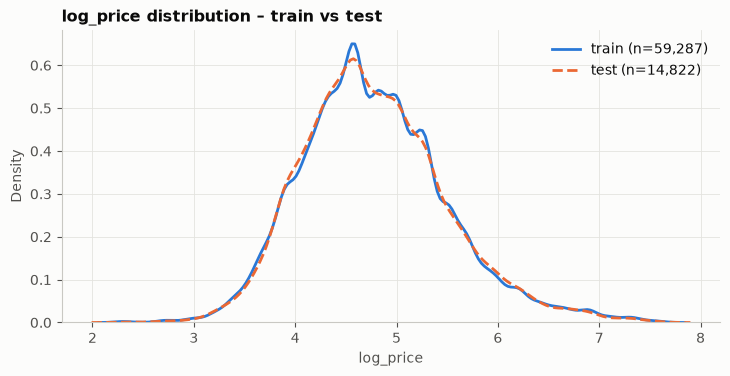

In [7]:
price_band = pd.qcut(y_all, 5, labels=False)          # stratify on price quintiles (EDA §15)
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.20, stratify=price_band, random_state=RANDOM_STATE)
print(f"Train: {len(X_train):,} rows ({len(X_train) / len(X_all):.0%}) | Test: {len(X_test):,} rows ({len(X_test) / len(X_all):.0%})")

compare = pd.DataFrame({
    "train": y_train.describe(percentiles=[.05, .25, .5, .75, .95]),
    "test": y_test.describe(percentiles=[.05, .25, .5, .75, .95])}).T
display(compare)
shares = pd.concat({
    "train": pd.concat([X_train["city"].value_counts(normalize=True), X_train["room_type"].value_counts(normalize=True)]),
    "test": pd.concat([X_test["city"].value_counts(normalize=True), X_test["room_type"].value_counts(normalize=True)])}, axis=1)
shares["difference (pp)"] = (shares["train"] - shares["test"]) * 100
display(shares.style.format({"train": "{:.1%}", "test": "{:.1%}", "difference (pp)": "{:+.2f}"}))

fig, ax = plt.subplots(figsize=(8.5, 3.8))
sns.kdeplot(y_train, ax=ax, color=BLUE, lw=2, label=f"train (n={len(y_train):,})")
sns.kdeplot(y_test, ax=ax, color=ORANGE, lw=2, ls="--", label=f"test (n={len(y_test):,})")
ax.set_title("log_price distribution – train vs test"); ax.set_xlabel("log_price"); ax.legend()
save(fig, "05_train_test_distribution")

**Decisions & justification**
- **80/20 hold-out split.** With ~74k rows, 20% (~14.8k listings) gives a precise final estimate while leaving ~59k for training and cross-validation.
- **Stratified on `log_price` quintiles.** The target is uneven across segments (EDA §15). Stratifying guarantees that both sets cover the whole price range. The table confirms the train and test distributions are almost identical, and the city and room-type shares differ by only fractions of a percentage point.
- **Fixed `random_state = 42`** makes the split reproducible for every group member.
- **The split happens before any learned step.** Every imputation value, encoding, threshold and scaler below is fitted on `X_train` only. `X_test` is not looked at again until the final evaluation in Stage 7.

## 6. Evidence that the engineered features are useful (training data only)

,type,Spearman ρ with log_price
accommodates,original,0.590
beds,original,0.482
guests_per_bathroom,engineered,0.473
bedrooms,original,0.408
guests_per_bedroom,engineered,0.332
bathrooms,original,0.282
dist_centre_km,engineered,-0.272
amenity_count,engineered,0.237
beds_per_guest,engineered,-0.220
longitude,original,-0.161


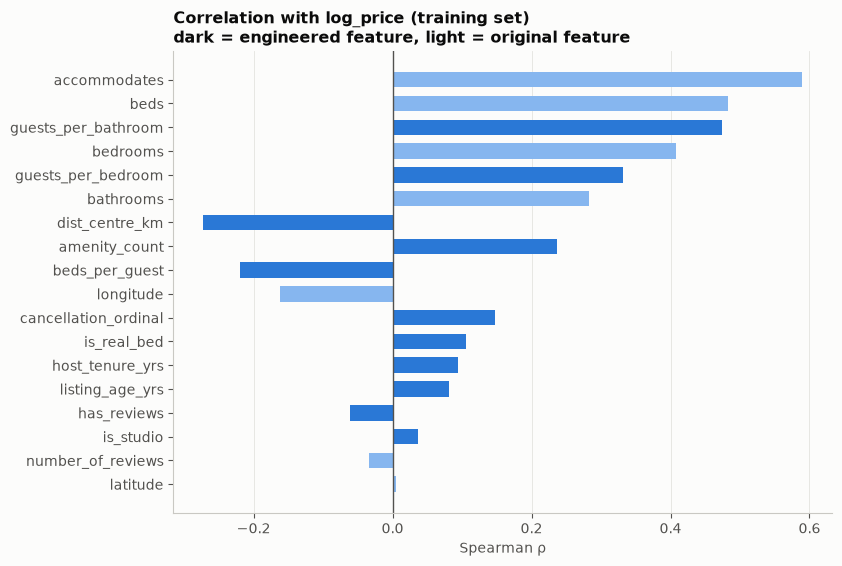

In [8]:
tmp = pp.LocationImputer().fit(X_train).transform(X_train)     # adds dist_centre_km (train-fitted)
feats = {"accommodates": "original", "bedrooms": "original", "beds": "original", "bathrooms": "original",
         "latitude": "original", "longitude": "original", "number_of_reviews": "original",
         "dist_centre_km": "engineered", "guests_per_bedroom": "engineered", "beds_per_guest": "engineered",
         "guests_per_bathroom": "engineered", "amenity_count": "engineered", "cancellation_ordinal": "engineered",
         "is_studio": "engineered", "is_real_bed": "engineered", "host_tenure_yrs": "engineered",
         "listing_age_yrs": "engineered", "has_reviews": "engineered"}
ev = pd.DataFrame({"type": feats, "Spearman ρ with log_price": {f: tmp[f].corr(y_train, method="spearman") for f in feats}})
ev = ev.reindex(ev["Spearman ρ with log_price"].abs().sort_values().index)
display(ev.iloc[::-1])

fig, ax = plt.subplots(figsize=(8.5, 6))
ax.barh(ev.index, ev["Spearman ρ with log_price"], color=[BLUE if t == "engineered" else BLUE_LIGHT for t in ev["type"]], height=.65)
ax.axvline(0, color=INK2, lw=1)
ax.set_title("Correlation with log_price (training set)\ndark = engineered feature, light = original feature")
ax.set_xlabel("Spearman ρ"); ax.grid(axis="y", visible=False)
save(fig, "06_engineered_feature_correlation")

**Reading the evidence**
- **`guests_per_bathroom` (ρ = 0.47)** is the strongest engineered feature. It is almost as strong as `beds` and stronger than raw `bathrooms` (0.28), so a "big but few bathrooms" listing is priced very differently from a small one.
- `guests_per_bedroom` (0.33) and `beds_per_guest` (−0.22) describe the **shape** of a listing that the raw counts cannot. A lower `beds_per_guest` means sofa beds and crowded budget listings, which are cheaper.
- **`dist_centre_km` (ρ = −0.27)** turns location from "no signal" (raw latitude ρ = 0.005) into a useful feature, as predicted in EDA §11.
- `amenity_count` (0.24) and `cancellation_ordinal` (0.15) add clear signal. `is_studio` is weak on its own (0.04), but it stops studios being read as "0 bedrooms = missing".
- These numbers are computed on the **training set only**, so the test set has not influenced which features we keep.

## 7. Missing values

In [9]:
strategy = {
    "neighbourhood": ("KNN (k=5) on lat/lon, fitted on training listings", "LocationImputer"),
    "latitude / longitude": ("neighbourhood → city median (only needed for form inputs)", "LocationImputer"),
    "host_response_rate": ("median + response_rate_missing flag", "SimpleImputer"),
    "review_scores_rating": ("median + review_score_missing / has_reviews flags", "SimpleImputer"),
    "listing_age_yrs": ("median + has_reviews flag", "SimpleImputer"),
    "days_since_last_review": ("median + has_reviews flag", "SimpleImputer"),
    "bathrooms": ("median (incl. 0 → missing)", "SimpleImputer"),
    "beds": ("median (incl. 0 → missing)", "SimpleImputer"),
    "bedrooms": ("median", "SimpleImputer"),
    "guests_per_bedroom / beds_per_guest / guests_per_bathroom": ("median (missing when an input count is missing)", "SimpleImputer"),
    "host_tenure_yrs": ("median", "SimpleImputer"),
    "host_identity_verified": ("mode", "SimpleImputer"),
}
cols = ["neighbourhood", "host_response_rate", "review_scores_rating", "listing_age_yrs", "days_since_last_review",
        "bathrooms", "beds", "bedrooms", "guests_per_bathroom", "beds_per_guest", "guests_per_bedroom",
        "host_tenure_yrs", "host_identity_verified", "latitude", "longitude"]
miss_train = pd.DataFrame({"missing in train": X_train[cols].isna().sum(),
                           "% train": X_train[cols].isna().mean() * 100}).sort_values("missing in train", ascending=False)
display(miss_train)
pd.DataFrame(strategy, index=["strategy", "implemented by"]).T

,missing in train,% train
host_response_rate,14640,24.693
review_scores_rating,13371,22.553
listing_age_yrs,12663,21.359
days_since_last_review,12636,21.313
neighbourhood,5540,9.344
bathrooms,311,0.525
guests_per_bathroom,311,0.525
host_identity_verified,147,0.248
host_tenure_yrs,147,0.248
beds,108,0.182


,strategy,implemented by
neighbourhood,"KNN (k=5) on lat/lon, fitted on training listings",LocationImputer
latitude / longitude,neighbourhood → city median (only needed for f...,LocationImputer
host_response_rate,median + response_rate_missing flag,SimpleImputer
review_scores_rating,median + review_score_missing / has_reviews flags,SimpleImputer
listing_age_yrs,median + has_reviews flag,SimpleImputer
days_since_last_review,median + has_reviews flag,SimpleImputer
bathrooms,median (incl. 0 → missing),SimpleImputer
beds,median (incl. 0 → missing),SimpleImputer
bedrooms,median,SimpleImputer
guests_per_bedroom / beds_per_guest / guests_per_bathroom,median (missing when an input count is missing),SimpleImputer


In [10]:
# How reliable is the KNN neighbourhood imputation? Hide 20% of the KNOWN training labels and predict them.
known = X_train.dropna(subset=["neighbourhood"])
k_fit, k_eval = train_test_split(known, test_size=0.2, random_state=RANDOM_STATE)
knn = KNeighborsClassifier(n_neighbors=5).fit(k_fit[["latitude", "longitude"]], k_fit["neighbourhood"])
acc = (knn.predict(k_eval[["latitude", "longitude"]]) == k_eval["neighbourhood"]).mean()
print(f"KNN neighbourhood accuracy on held-out training listings: {acc:.1%} (619 possible labels)")
print(f"Majority-class baseline: {k_eval['neighbourhood'].value_counts(normalize=True).iloc[0]:.1%}")

loc = pp.LocationImputer().fit(X_train)
filled = loc.transform(X_train)
print(f"\nTrain neighbourhoods filled: {X_train['neighbourhood'].isna().sum():,} → remaining missing: {filled['neighbourhood'].isna().sum()}")
print("Filled share by city:")
display((X_train.assign(was_missing=X_train["neighbourhood"].isna()).groupby("city")["was_missing"].mean() * 100)
        .round(1).to_frame("% neighbourhood imputed"))

KNN neighbourhood accuracy on held-out training listings: 95.5% (619 possible labels)
Majority-class baseline: 4.0%



Train neighbourhoods filled: 5,540 → remaining missing: 0
Filled share by city:


,% neighbourhood imputed
city,
Boston,0.000
Chicago,17.300
DC,14.100
LA,24.500
NYC,0.000
SF,0.100


**Decisions & justification**
- **`neighbourhood`: spatial KNN imputation.** Latitude/longitude are never missing, and a neighbourhood is simply a region on the map. Predicting it from the 5 nearest *training* listings is far more faithful than "Unknown" or the mode. On held-out training listings it recovers the correct neighbourhood **95.5%** of the time (the majority-class baseline is 4.0%). The KNN uses only coordinates and labels, never the price, so it cannot leak the target.
- **Numeric fields: median**, because the distributions are skewed (EDA §7) and the median is robust to the large-listing tail. The medians come from the training data.
- **Review / response fields: median plus a missing-indicator flag.** Missingness here is *informative*: never-reviewed listings are pricier (EDA §3). The flags keep that information, while the median just gives the models a neutral value.
- **Booleans: mode** (only 0.25% missing, and missingness is not related to price, p = 0.55; EDA §3).
- **We do not drop rows with missing values.** That would discard up to ~25% of the data and bias it toward reviewed, established listings.

## 8. Outliers

,train min,lower cap (0.5%),upper cap (99.5%),train max,rows clipped,% clipped
accommodates,1.000,1.000,15.000,16.000,263,0.444
bathrooms,0.500,1.000,4.000,8.000,425,0.717
bedrooms,0.000,0.000,5.000,10.000,154,0.260
beds,1.000,1.000,8.000,18.000,224,0.378
guests_per_bedroom,0.200,1.000,7.000,16.000,464,0.783
beds_per_guest,0.062,0.200,2.000,16.000,315,0.531
guests_per_bathroom,0.125,0.500,8.000,32.000,384,0.648
amenity_count,0.000,0.000,40.000,78.000,287,0.484


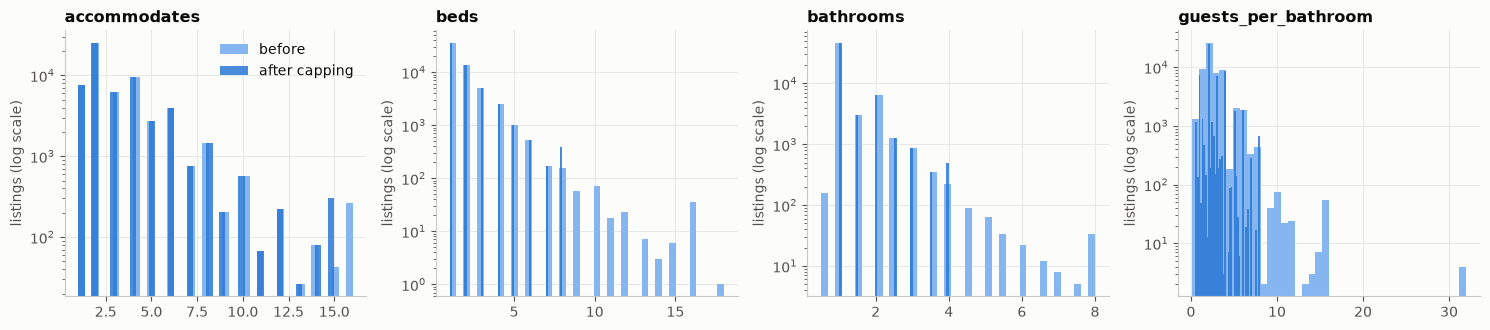

In [11]:
clip_cols = ["accommodates", "bathrooms", "bedrooms", "beds", "guests_per_bedroom", "beds_per_guest",
             "guests_per_bathroom", "amenity_count"]
imputed = X_train[clip_cols].fillna(X_train[clip_cols].median())
w = pp.Winsorizer().fit(imputed)
clipped = w.transform(imputed)
out = pd.DataFrame({"train min": imputed.min(), "lower cap (0.5%)": w.lower_, "upper cap (99.5%)": w.upper_,
                    "train max": imputed.max(), "rows clipped": (imputed != clipped).sum(),
                    "% clipped": (imputed != clipped).mean() * 100})
display(out)

fig, axes = plt.subplots(1, 4, figsize=(15, 3.4))
for ax, c in zip(axes, ["accommodates", "beds", "bathrooms", "guests_per_bathroom"]):
    ax.hist(imputed[c], bins=40, color=BLUE_LIGHT, label="before")
    ax.hist(clipped[c], bins=40, color=BLUE, alpha=.85, label="after capping")
    ax.set_title(c); ax.set_yscale("log"); ax.set_ylabel("listings (log scale)")
axes[0].legend()
fig.tight_layout()
save(fig, "08_winsorising")

**Decisions & justification**
- **We do not delete outlier rows.** The EDA showed that extreme values are mostly genuine large properties, and that the IQR rule is meaningless here: it flags 24k normal bedroom counts (EDA §7). Deleting them would bias the model against large homes, which hosts do need prices for.
- **Winsorising at the training set's 0.5th / 99.5th percentiles, for linear models only.** Linear/Ridge/Lasso fit squared errors with a single slope, so a few 16-guest or 8-bathroom listings can tilt the whole line. Capping them (e.g. at the train's 99.5th percentile of `accommodates`) limits that leverage while keeping the rows. Only a small share of rows is changed.
- **Tree models get no capping.** Random Forest and Gradient Boosting split on thresholds, so an extreme x-value only affects the leaf it falls in. They are naturally robust.
- **Target outliers:** apart from the two invalid prices (§3), the target is not trimmed. The log transform already reduced the skew from 4.30 to 0.51 (EDA §6).
- The caps are **learned on the training set** and then applied unchanged to the test set and to new listings.

## 9. Encoding categorical variables

In [12]:
enc = pd.DataFrame([
    ("room_type", 3, "One-hot", "Low cardinality, nominal, strongest feature (η² = 0.375)"),
    ("city", 6, "One-hot", "Low cardinality, nominal"),
    ("property_type", 35, "Rare levels (<100 train rows) → 'Other', then one-hot", "23 levels have <100 rows (EDA §8)"),
    ("cancellation_policy", 5, "Ordinal 0/1/2 (super_strict merged into strict)", "Natural order, monotonic with price (EDA §9)"),
    ("bed_type", 5, "Binary is_real_bed", "97% one level (EDA §8)"),
    ("neighbourhood (city | name)", X_train["neighbourhood"].nunique(), "Smoothed target encoding, cross-fitted (5-fold)", "High cardinality, 33% of levels < 10 rows (EDA §8)"),
    ("amenities", X_train["amenity_list"].explode().nunique(), "Multi-hot for amenities in ≥ 2% of train rows", "60 tokens in <1% of rows (EDA §12)"),
    ("booleans", 2, "0/1", "Already binary"),
], columns=["feature", "levels (train)", "encoding", "why"]).set_index("feature")
display(enc)

rare = pp.RareCategoryGrouper(min_count=100).fit(X_train[["property_type"]])
kept_levels = sorted(rare.keep_["property_type"])
print(f"property_type: {X_train['property_type'].nunique()} levels → {len(kept_levels) + 1} after grouping")
print("Kept:", kept_levels)

amen = pp.AmenityEncoder(min_prevalence=0.02).fit(X_train[["amenity_list"]])
print(f"\nAmenities kept at ≥2% prevalence: {len(amen.vocabulary_)} of {len(amen.prevalence_)}")

,levels (train),encoding,why
feature,,,
room_type,3,One-hot,"Low cardinality, nominal, strongest feature (η..."
city,6,One-hot,"Low cardinality, nominal"
property_type,35,"Rare levels (<100 train rows) → 'Other', then ...",23 levels have <100 rows (EDA §8)
cancellation_policy,5,Ordinal 0/1/2 (super_strict merged into strict),"Natural order, monotonic with price (EDA §9)"
bed_type,5,Binary is_real_bed,97% one level (EDA §8)
neighbourhood (city | name),626,"Smoothed target encoding, cross-fitted (5-fold)","High cardinality, 33% of levels < 10 rows (EDA..."
amenities,114,Multi-hot for amenities in ≥ 2% of train rows,60 tokens in <1% of rows (EDA §12)
booleans,2,0/1,Already binary


property_type: 34 levels → 12 after grouping
Kept: ['Apartment', 'Bed & Breakfast', 'Bungalow', 'Condominium', 'Dorm', 'Guesthouse', 'House', 'Loft', 'Other', 'Townhouse', 'Villa']



Amenities kept at ≥2% prevalence: 58 of 114


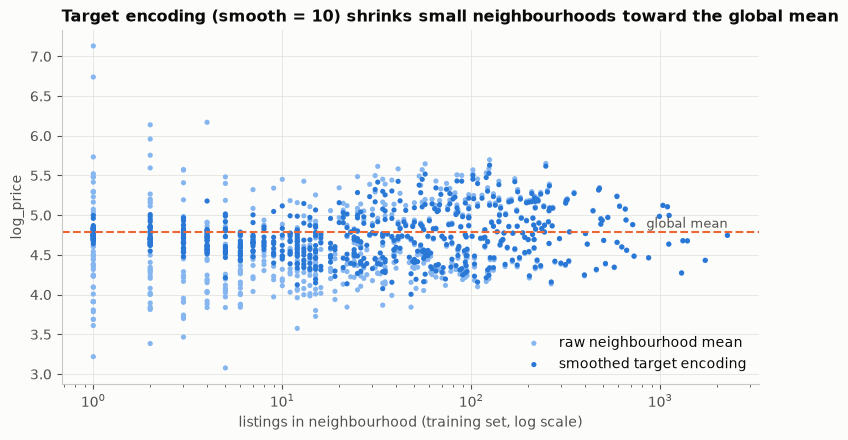

Neighbourhoods with < 5 training listings: 129 | mean |raw − global| = 0.584 vs |encoded − global| = 0.096


In [13]:
# Target encoding: how smoothing protects small neighbourhoods
te_input = loc.transform(X_train)[["neighbourhood"]]
TE_SMOOTH = 10   # m-estimate strength, chosen by the CV comparison in the next cell
te = TargetEncoder(target_type="continuous", smooth=TE_SMOOTH).fit(te_input, y_train)
stats_nb = pd.DataFrame({"n": te_input["neighbourhood"].value_counts(),
                         "raw mean": y_train.groupby(te_input["neighbourhood"]).mean()})
stats_nb["encoded"] = pd.Series(te.encodings_[0], index=te.categories_[0]).reindex(stats_nb.index)
global_mean = y_train.mean()

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.scatter(stats_nb["n"], stats_nb["raw mean"], s=14, color=BLUE_LIGHT, label="raw neighbourhood mean", edgecolors="none")
ax.scatter(stats_nb["n"], stats_nb["encoded"], s=14, color=BLUE, label="smoothed target encoding", edgecolors="none")
ax.axhline(global_mean, color=ORANGE, lw=1.5, ls="--"); ax.text(stats_nb["n"].max(), global_mean + .06, "global mean", ha="right", color=INK2, fontsize=9)
ax.set_xscale("log"); ax.set_xlabel("listings in neighbourhood (training set, log scale)"); ax.set_ylabel("log_price")
ax.set_title(f"Target encoding (smooth = {TE_SMOOTH}) shrinks small neighbourhoods toward the global mean"); ax.legend(loc="lower right")
save(fig, "09_target_encoding_shrinkage")
small = stats_nb[stats_nb["n"] < 5]
print(f"Neighbourhoods with < 5 training listings: {len(small)} | mean |raw − global| = "
      f"{(small['raw mean'] - global_mean).abs().mean():.3f} vs |encoded − global| = {(small['encoded'] - global_mean).abs().mean():.3f}")

In [14]:
# Choosing the smoothing strength: 5-fold CV on the training set (listing features)
cv = KFold(5, shuffle=True, random_state=RANDOM_STATE)
rows = []
for sm in ["auto", 5, 10, 20, 50]:
    row = {"smooth": str(sm), "weight of own mean for n = 1": "data-driven" if sm == "auto" else f"{1 / (1 + sm):.0%}"}
    for name, kind, model in [("Ridge", "linear", Ridge()), ("HistGB", "tree", HistGradientBoostingRegressor(random_state=RANDOM_STATE))]:
        pipe = Pipeline([("prep", pp.build_preprocessor(kind, "listing", te_smooth=sm)), ("model", model)])
        row[f"{name} CV RMSE"] = -cross_val_score(pipe, X_train, y_train, cv=cv, scoring="neg_root_mean_squared_error").mean()
    rows.append(row)
pd.DataFrame(rows).set_index("smooth")

,weight of own mean for n = 1,Ridge CV RMSE,HistGB CV RMSE
smooth,,,
auto,data-driven,0.417,0.393
5,17%,0.417,0.393
10,9%,0.417,0.393
20,5%,0.418,0.393
50,2%,0.420,0.393


**Decisions & justification**
- **One-hot** for `room_type`, `city` and `property_type` (after grouping): these are nominal with few levels, so there is no false ordering and only a small number of columns. For linear models we **drop the first dummy**, which avoids the dummy-variable trap (perfect collinearity with the intercept). Tree models keep all dummies.
- **Rare-level grouping** (fewer than 100 training rows → `Other`): levels such as *Lighthouse* or *Island* have 1–10 rows. Their coefficients would be pure noise, and a level missing from the training split would break encoding. The threshold is learned on the training data, and unseen levels at prediction time also map to `Other`.
- **Ordinal encoding** for `cancellation_policy`, because its levels have a real order that matches price (EDA §9).
- **Target encoding** for `neighbourhood` (600+ levels): one-hot would add 600+ sparse columns and overfit tiny neighbourhoods. Two safeguards are built in:
  1. **Smoothing (m-estimate, `smooth = 10`):** encoding = (n · neighbourhood mean + 10 · global mean) / (n + 10). A neighbourhood with 1 listing gets only 1/11 ≈ 9% weight on its own price, while one with 500 listings gets 98%. For the 129 neighbourhoods with fewer than 5 training listings, the average distance from the global mean falls from **0.584 (raw) to 0.096 (encoded)**. The plot shows the tiny neighbourhoods pulled onto the global mean.
     - **How 10 was chosen:** we first tried sklearn's `"auto"` smoothing, but it left 1-listing neighbourhoods almost unshrunk (values from 3.2 to 7.1). The CV table shows that `smooth` from 5 to 20 gives the **same accuracy** as `"auto"` (RMSE within ±0.001). We picked 10 because it is equally accurate and much **more robust for rare or new neighbourhoods** in the deployed tool. Only a very strong 50 starts to hurt Ridge.
  2. **Cross-fitting:** in `fit_transform`, each training row is encoded with the means of the *other* 4 folds, so a row never sees its own price. The test set is encoded with means from the full training set.
- **Amenities:** multi-hot encoding of amenities present in at least 2% of training listings. Rarer amenities (e.g. *Ski in/Ski out*) have too few examples to learn from.

## 10. Scaling

In [15]:
prep_lin = pp.build_preprocessor("linear", "listing")
Z = prep_lin.fit_transform(X_train, y_train)
num_out = [c for c in pp.LISTING_NUMERIC if c in Z.columns] + ["neighbourhood"]
scale_check = pd.DataFrame({"train mean": Z[num_out].mean(), "train std": Z[num_out].std()})
Zt = prep_lin.transform(X_test)
scale_check["test mean"] = Zt[num_out].mean(); scale_check["test std"] = Zt[num_out].std()
scale_check

,train mean,train std,test mean,test std
accommodates,-0.000,1.000,-0.013,0.973
bathrooms,0.000,1.000,-0.009,0.983
bedrooms,-0.000,1.000,0.001,0.984
beds,-0.000,1.000,-0.005,0.984
guests_per_bedroom,0.000,1.000,-0.008,0.985
beds_per_guest,0.000,1.000,0.008,0.994
guests_per_bathroom,0.000,1.000,-0.007,0.990
amenity_count,0.000,1.000,-0.017,0.989
cancellation_ordinal,-0.000,1.000,-0.001,0.997
latitude,-0.000,1.000,-0.017,1.003


**Decisions & justification**
- **StandardScaler (z-score) for the linear models only.** Ridge and Lasso penalise the *size* of coefficients, so features on large scales (a rating of 20–100, a distance of 0–80 km) would be penalised differently from counts of 1–16. Scaling puts every feature on a common scale, making regularisation fair and coefficients comparable.
- **No scaling for trees:** split thresholds do not depend on units.
- **Binary and dummy features are left as 0/1**, which keeps them interpretable.
- The **train** mean is exactly 0 and std exactly 1. The **test** values are close but not exact, which is the expected sign that the scaler was fitted only on the training data and merely *applied* to the test set.

## 11. Fitting the full pipelines

In [16]:
pipelines, shapes = {}, []
for kind in ["linear", "tree"]:
    for fs in ["listing", "full"]:
        p = pp.build_preprocessor(kind, fs)
        Ztr = p.fit_transform(X_train, y_train)      # fit on TRAIN only
        Zte = p.transform(X_test)                    # test is only transformed
        pipelines[(kind, fs)] = p
        shapes.append({"model family": kind, "feature set": fs, "train shape": Ztr.shape, "test shape": Zte.shape,
                       "NaN in train": int(Ztr.isna().sum().sum()), "NaN in test": int(Zte.isna().sum().sum()),
                       "dropped by corr. filter": len(p.named_steps["corr_filter"].dropped_)})
display(pd.DataFrame(shapes))
pipelines[("tree", "listing")]

,model family,feature set,train shape,test shape,NaN in train,NaN in test,dropped by corr. filter
0,linear,listing,"(59287, 87)","(14822, 87)",0,0,5
1,linear,full,"(59287, 96)","(14822, 96)",0,0,6
2,tree,listing,"(59287, 90)","(14822, 90)",0,0,5
3,tree,full,"(59287, 99)","(14822, 99)",0,0,6


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('location', ...), ('columns', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](34,)","['city','room_type','property_type',...,'log_number_of_reviews', 'review_score_missing','response_rate_missing']"
,n_neighbors,5
Name,Type,Value
city_centroid_,DataFrame,lati...769 -122.427
feature_names_in_,"ndarray[object](34,)","['city','room_type','property_type',...,'log_number_of_reviews', 'review_score_missing','response_rate_missing']"
knn_,KNeighborsClassifier,KNeighborsClassifier()


In [17]:
Z_tree = pipelines[("tree", "listing")].transform(X_train)
groups = {"numeric": [c for c in Z_tree if c in pp.LISTING_NUMERIC],
          "binary flags": [c for c in Z_tree if c in pp.LISTING_BINARY],
          "one-hot": [c for c in Z_tree if c.startswith(("room_type_", "city_", "property_type_"))],
          "target-encoded": [c for c in Z_tree if c == "neighbourhood"],
          "amenities": [c for c in Z_tree if c.startswith("amen_")]}
for g, cs in groups.items():
    print(f"{g:15s} ({len(cs):2d}): {', '.join(cs[:12])}{' …' if len(cs) > 12 else ''}")

numeric         (12): accommodates, bathrooms, bedrooms, beds, guests_per_bedroom, beds_per_guest, guests_per_bathroom, amenity_count, cancellation_ordinal, latitude, longitude, dist_centre_km
binary flags    ( 4): cleaning_fee, instant_bookable, is_studio, is_real_bed
one-hot         (20): room_type_Entire home/apt, room_type_Private room, room_type_Shared room, city_Boston, city_Chicago, city_DC, city_LA, city_NYC, city_SF, property_type_Apartment, property_type_Bed & Breakfast, property_type_Bungalow …
target-encoded  ( 1): neighbourhood
amenities       (53): amen_24_hour_check_in, amen_air_conditioning, amen_bathtub, amen_bed_linens, amen_breakfast, amen_buzzer_wireless_intercom, amen_cable_tv, amen_carbon_monoxide_detector, amen_cat_s, amen_coffee_maker, amen_cooking_basics, amen_dishwasher …


There are **four preprocessing pipelines**: two model families × two feature sets. All of them produce **no missing values** on either split.
- **`linear`** pipelines feed Linear, Ridge and Lasso Regression (winsorised, scaled, first dummy dropped).
- **`tree`** pipelines feed Random Forest and Gradient Boosting (unscaled, all dummies kept).
- **`listing`** is the deployable feature set: only what a host enters in the form.
- **`full`** adds host profile and booking-history features (see §13).

## 12. Feature selection

In [18]:
# (a) Variance filter: near-constant binary features on the TRAINING set
binary_candidates = ["host_has_profile_pic", "is_real_bed", "cleaning_fee", "instant_bookable",
                     "host_identity_verified", "is_studio", "amenities_empty"]
var = pd.DataFrame({"share of majority value": [X_train[c].value_counts(normalize=True).iloc[0] for c in binary_candidates]},
                   index=binary_candidates).sort_values("share of majority value", ascending=False)
var["decision"] = np.where(var["share of majority value"] > 0.99, "drop (near-constant)", "keep")
display(var)

amen_prev = amen.prevalence_.sort_values(ascending=False)
print("Most common amenities (train prevalence):", amen_prev.head(4).round(3).to_dict())

,share of majority value,decision
host_has_profile_pic,0.997,drop (near-constant)
amenities_empty,0.990,drop (near-constant)
is_real_bed,0.972,keep
is_studio,0.908,keep
instant_bookable,0.737,keep
cleaning_fee,0.734,keep
host_identity_verified,0.672,keep


Most common amenities (train prevalence): {'Internet': 0.967, 'Kitchen': 0.912, 'Heating': 0.906, 'Essentials': 0.864}


In [19]:
# (b) Correlation filter (learned inside the pipeline on the training set, |r| > 0.9)
p = pipelines[("tree", "full")]
dropped = pd.DataFrame([(f, partner, r) for f, (partner, r) in p.named_steps["corr_filter"].dropped_.items()],
                       columns=["dropped feature", "kept (correlated) feature", "|r|"]).set_index("dropped feature")
dropped

,kept (correlated) feature,|r|
dropped feature,,
review_score_missing,has_reviews,0.964
amen_dishes_and_silverware,amen_cooking_basics,0.930
amen_oven,amen_cooking_basics,0.925
amen_refrigerator,amen_cooking_basics,0.910
amen_stove,amen_cooking_basics,0.934
amen_washer,amen_dryer,0.955


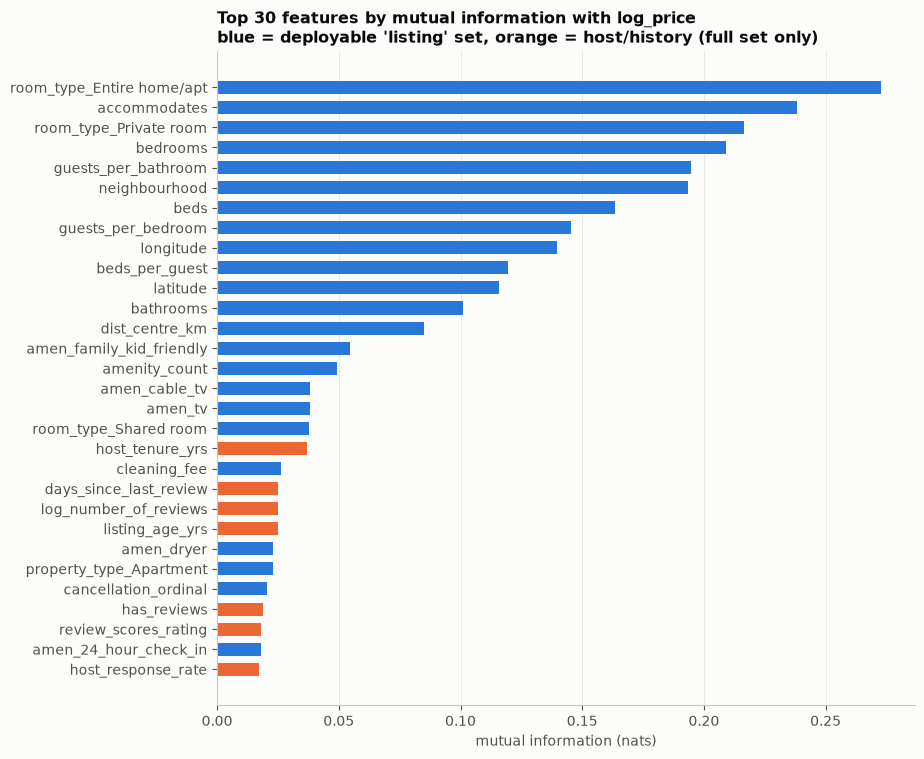

Features with MI < 0.005: 33 of 99
amen_wheelchair_accessible        0.005
amen_cat_s                        0.005
city_Boston                       0.005
amen_coffee_maker                 0.004
amen_bathtub                      0.004
amen_pets_live_on_this_property   0.004
amen_cooking_basics               0.004
amen_bed_linens                   0.004
amen_hot_water                    0.003
property_type_Dorm                0.003
host_identity_verified            0.003
amen_internet                     0.003
amen_carbon_monoxide_detector     0.003
amen_private_living_room          0.002
city_Chicago                      0.002
amen_keypad                       0.002
property_type_Condominium         0.002
property_type_Loft                0.002
amen_long_term_stays_allowed      0.002
amen_first_aid_kit                0.002
property_type_Bed & Breakfast     0.001
property_type_Villa               0.001
property_type_Guesthouse          0.001
amen_microwave                    0.001
amen_

In [20]:
# (c) Filter method: mutual information with log_price (captures non-linear dependence), training sample
Ztr = pipelines[("tree", "full")].transform(X_train)
sample = Ztr.sample(15000, random_state=RANDOM_STATE)
discrete = [sample[c].nunique() <= 2 for c in sample.columns]
mi = pd.Series(mutual_info_regression(sample, y_train.loc[sample.index], discrete_features=discrete,
                                      random_state=RANDOM_STATE), index=sample.columns).sort_values(ascending=False)
listing_cols = set(pipelines[("tree", "listing")].named_steps["corr_filter"].keep_)

fig, ax = plt.subplots(figsize=(9, 8.5))
top = mi.head(30)[::-1]
ax.barh(top.index, top.values, color=[BLUE if c in listing_cols else ORANGE for c in top.index], height=.65)
ax.set_title("Top 30 features by mutual information with log_price\nblue = deployable 'listing' set, orange = host/history (full set only)")
ax.set_xlabel("mutual information (nats)"); ax.grid(axis="y", visible=False)
save(fig, "12_mutual_information")
print(f"Features with MI < 0.005: {(mi < 0.005).sum()} of {len(mi)}")
print(mi[mi < 0.005].round(4).to_string())

**Decisions & justification.** Feature selection uses three complementary methods. All of them are computed on **training data only**:
1. **Variance filter (> 99% one value):** `host_has_profile_pic` (99.7% True) and `amenities_empty` (99.0% False, MI ≈ 0.001) cannot separate prices, so both are **dropped** from the feature lists. The other flags have enough spread.
2. **Correlation filter (|r| > 0.9, inside the pipeline):** it removes redundant columns that carry the same information:
   - the kitchen cluster (*Oven*, *Stove*, *Refrigerator*, *Dishes and silverware* ≈ *Cooking basics*; these are listed together by Airbnb's template);
   - *Washer*, which duplicates *Dryer*;
   - `review_score_missing`, which duplicates `has_reviews` (r ≈ 0.97).

   This reduces multicollinearity for the linear models and speeds up training. Category dummies are protected from this filter.
3. **Mutual information (filter method):**
   - The strongest features are `neighbourhood` (target-encoded), `accommodates`, `room_type`, `dist_centre_km`, bedrooms/beds and the location coordinates. This confirms the EDA.
   - Most booking-history features rank low, which supports building the deployable model without them.
   - Features with near-zero MI are **not blindly removed**, because MI looks at one feature at a time and misses interactions.

Final selection is left to the models: **Lasso** performs embedded selection by shrinking useless coefficients to zero, and tree importances will be compared in Stage 6. Keeping a slightly larger, clean feature set here is deliberate.

## 13. Leakage prevention – with a demonstration

In [21]:
checklist = pd.DataFrame([
    ("Split before any learned step", "train_test_split in §5 happens before every fit", "✔"),
    ("Imputation statistics", "SimpleImputer / LocationImputer fitted on X_train only", "✔"),
    ("Rare-level thresholds & amenity vocabulary", "Learned from training counts only", "✔"),
    ("Target encoding", "Smoothed + 5-fold cross-fitting; test encoded with train means", "✔"),
    ("Winsorising caps & scaler", "Quantiles / mean / std from X_train only", "✔"),
    ("Correlation filter", "Correlations computed on X_train only", "✔"),
    ("Cross-validation", "The whole preprocessor sits inside the model Pipeline → refitted per fold", "✔"),
    ("Post-listing (temporal) features", "Separate 'listing' feature set without reviews / response history", "✔"),
    ("Text that may contain the price", "name / description dropped", "✔"),
    ("Test set usage", "Only transformed here; evaluated once in Stage 7", "✔"),
], columns=["risk", "how it is prevented", "status"]).set_index("risk")
checklist

,how it is prevented,status
risk,,
Split before any learned step,train_test_split in §5 happens before every fit,✔
Imputation statistics,SimpleImputer / LocationImputer fitted on X_tr...,✔
Rare-level thresholds & amenity vocabulary,Learned from training counts only,✔
Target encoding,Smoothed + 5-fold cross-fitting; test encoded ...,✔
Winsorising caps & scaler,Quantiles / mean / std from X_train only,✔
Correlation filter,Correlations computed on X_train only,✔
Cross-validation,The whole preprocessor sits inside the model P...,✔
Post-listing (temporal) features,Separate 'listing' feature set without reviews...,✔
Text that may contain the price,name / description dropped,✔


In [22]:
# Demonstration: what goes wrong if neighbourhood is target-encoded BEFORE cross-validation.
cv = KFold(5, shuffle=True, random_state=RANDOM_STATE)
base_cols = ["accommodates", "bedrooms", "bathrooms", "room_type", "neighbourhood"]
D = loc.transform(X_train)[base_cols].copy()
D[["accommodates", "bedrooms", "bathrooms"]] = D[["accommodates", "bedrooms", "bathrooms"]].fillna(D[["accommodates", "bedrooms", "bathrooms"]].median())

# WRONG: plain mean-encoding computed on all training rows (each row sees its own price, and so does every CV fold)
leaky = D.copy()
leaky["neighbourhood"] = D["neighbourhood"].map(y_train.groupby(D["neighbourhood"]).mean())
leaky_model = Pipeline([("ct", ColumnTransformer([("num", StandardScaler(), ["accommodates", "bedrooms", "bathrooms", "neighbourhood"]),
                                                   ("cat", OneHotEncoder(drop="first"), ["room_type"])])), ("ridge", Ridge())])
# RIGHT: target encoding inside the pipeline (fitted on each training fold, cross-fitted)
safe_model = Pipeline([("ct", ColumnTransformer([("num", StandardScaler(), ["accommodates", "bedrooms", "bathrooms"]),
                                                  ("cat", OneHotEncoder(drop="first"), ["room_type"]),
                                                  ("te", TargetEncoder(target_type="continuous", smooth="auto"), ["neighbourhood"])])), ("ridge", Ridge())])
res = {}
for name, model, data in [("leaky (encode before CV)", leaky_model, leaky), ("leakage-safe (encode inside CV)", safe_model, D)]:
    res[name] = -cross_val_score(model, data, y_train, cv=cv, scoring="neg_root_mean_squared_error")
leak_demo = pd.DataFrame({k: {"CV RMSE (mean)": v.mean(), "CV RMSE (std)": v.std()} for k, v in res.items()}).T
display(leak_demo)

# The optimism is concentrated in small neighbourhoods, where one listing's own price dominates its group mean
small_nb = D["neighbourhood"].map(D["neighbourhood"].value_counts()) < 10
err = {}
for name, model, data in [("leaky", leaky_model, leaky), ("safe", safe_model, D)]:
    pred = pd.Series(np.nan, index=data.index)
    for tr, va in cv.split(data):
        pred.iloc[va] = model.fit(data.iloc[tr], y_train.iloc[tr]).predict(data.iloc[va])
    err[name] = ((pred - y_train) ** 2)[small_nb].mean() ** .5
print(f"RMSE on listings in neighbourhoods with < 10 listings ({small_nb.sum():,} rows): "
      f"leaky {err['leaky']:.4f} vs safe {err['safe']:.4f}")

,CV RMSE (mean),CV RMSE (std)
leaky (encode before CV),0.434,0.005
leakage-safe (encode inside CV),0.438,0.006


RMSE on listings in neighbourhoods with < 10 listings (713 rows): leaky 0.5086 vs safe 0.6026


**Result.** The leaky version reports a **lower (better-looking) RMSE**. Overall the gap is small (0.434 vs 0.438), because most neighbourhoods are large. For the 713 listings in **neighbourhoods with fewer than 10 listings**, however, the leaky model looks far better (**0.509 vs 0.603**, i.e. 16% lower error). There, a listing's own price makes up a large part of its neighbourhood mean, so the model is partly "shown the answer". That score is **optimistic and would not hold on genuinely new listings**. The leakage-safe version gives the honest estimate. This is exactly why every learned step lives inside the sklearn `Pipeline`.

## 14. End-to-end sanity check (5-fold CV on the training set only)

This is **not model selection** (that is Stage 6). It only checks two things: that the pipelines run end to end inside cross-validation, and that the preprocessing and feature-engineering decisions help. The comparison has three levels:
- **Baseline:** 4 size counts + one-hot room type and city, median-imputed. No engineering.
- **Listing set:** all Stage 4 preprocessing, deployable features only.
- **Full set:** listing set plus host and booking-history features.

We test each with a linear model (Ridge) and a tree model (HistGradientBoosting), both with default hyper-parameters.

,model,features,CV RMSE (log),± std,CV R²
0,Ridge,baseline,0.484,0.006,0.547
1,Ridge,listing,0.417,0.006,0.663
2,Ridge,full,0.408,0.006,0.678
3,HistGB,baseline,0.468,0.006,0.576
4,HistGB,listing,0.393,0.006,0.701
5,HistGB,full,0.378,0.005,0.723


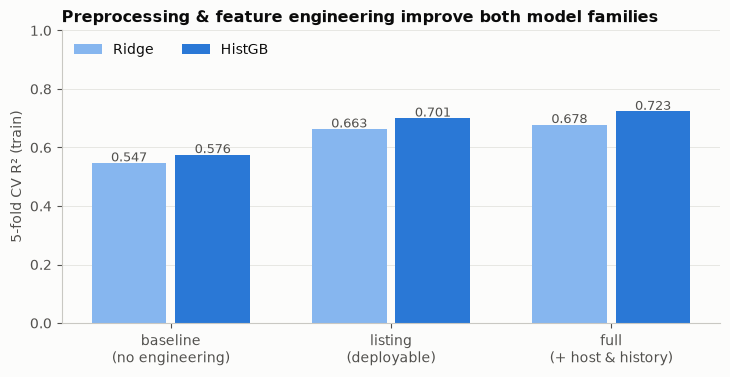

In [23]:
from sklearn.impute import SimpleImputer
size = ["accommodates", "bathrooms", "bedrooms", "beds"]
baseline_prep = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), size),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), ["room_type", "city"])])

configs = {
    ("Ridge", "baseline"): Pipeline([("prep", baseline_prep), ("model", Ridge())]),
    ("Ridge", "listing"): Pipeline([("prep", pp.build_preprocessor("linear", "listing")), ("model", Ridge())]),
    ("Ridge", "full"): Pipeline([("prep", pp.build_preprocessor("linear", "full")), ("model", Ridge())]),
    ("HistGB", "baseline"): Pipeline([("prep", baseline_prep), ("model", HistGradientBoostingRegressor(random_state=RANDOM_STATE))]),
    ("HistGB", "listing"): Pipeline([("prep", pp.build_preprocessor("tree", "listing")), ("model", HistGradientBoostingRegressor(random_state=RANDOM_STATE))]),
    ("HistGB", "full"): Pipeline([("prep", pp.build_preprocessor("tree", "full")), ("model", HistGradientBoostingRegressor(random_state=RANDOM_STATE))]),
}
rows = []
for (model, fs), pipe in configs.items():
    rmse = -cross_val_score(pipe, X_train, y_train, cv=cv, scoring="neg_root_mean_squared_error")
    r2 = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="r2")
    rows.append({"model": model, "features": fs, "CV RMSE (log)": rmse.mean(), "± std": rmse.std(), "CV R²": r2.mean()})
sanity = pd.DataFrame(rows)
display(sanity)

fig, ax = plt.subplots(figsize=(8.5, 3.8))
order = ["baseline", "listing", "full"]
xs = np.arange(len(order)); wbar = .38
for i, (m, color) in enumerate([("Ridge", BLUE_LIGHT), ("HistGB", BLUE)]):
    vals = sanity[sanity["model"] == m].set_index("features").loc[order, "CV R²"]
    bars = ax.bar(xs + (i - .5) * wbar, vals, width=wbar - .04, color=color, label=m)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + .005, f"{v:.3f}", ha="center", fontsize=9, color=INK2)
ax.set_xticks(xs); ax.set_xticklabels(["baseline\n(no engineering)", "listing\n(deployable)", "full\n(+ host & history)"])
ax.set_ylabel("5-fold CV R² (train)"); ax.set_ylim(0, 1); ax.legend(loc="upper left", ncol=2)
ax.set_title("Preprocessing & feature engineering improve both model families"); ax.grid(axis="x", visible=False)
save(fig, "14_sanity_check")

**Reading the result**
- **Stage 4 preprocessing gives a large gain for both model families:**
  - Ridge: R² 0.547 → 0.663, RMSE 0.484 → 0.417.
  - HistGB: R² 0.576 → 0.701, RMSE 0.468 → 0.393.
  - The engineered location, neighbourhood, amenity and ratio features explain an extra **~12 percentage points** of price variance.
- **The tree model is better at every level**, as predicted by the non-linearities and interactions in EDA §10. Hyper-parameter tuning in Stage 7 should widen the gap.
- **The full set adds only ~0.015–0.023 R²** over the deployable **listing** set (HistGB RMSE 0.393 → 0.378). The history features (reviews, response rate, listing age) are genuinely informative but *modest*, and a brand-new listing does not have them (EDA §16). **Decision:** deploy the **listing** model, and report the full model as an "existing hosts" upper bound in Stage 6.
- The fold-to-fold std is only ~0.006, so the pipeline is stable across data subsets.

## 15. Saving artefacts for Stage 6 (model development)

In [24]:
pd.concat([X_train, y_train], axis=1).to_pickle(DATA_DIR / "train_clean.pkl")
pd.concat([X_test, y_test], axis=1).to_pickle(DATA_DIR / "test_clean.pkl")
pd.DataFrame({"id": valid.loc[X_train.index, "id"], "split": "train"}).pipe(
    lambda d: pd.concat([d, pd.DataFrame({"id": valid.loc[X_test.index, "id"], "split": "test"})])
).to_csv(DATA_DIR / "split_ids.csv", index=False)

for (kind, fs), p in pipelines.items():
    joblib.dump(p, MODEL_DIR / f"preprocessor_{kind}_{fs}.joblib")
feature_names = {f"{kind}_{fs}": list(p.named_steps["corr_filter"].keep_) for (kind, fs), p in pipelines.items()}
(MODEL_DIR / "feature_names.json").write_text(json.dumps(feature_names, indent=2))

for f in sorted(list(DATA_DIR.glob("*")) + list(MODEL_DIR.glob("*"))):
    print(f"{str(f):45s} {f.stat().st_size / 1e6:6.2f} MB")

data\processed\split_ids.csv                    1.13 MB
data\processed\test_clean.pkl                   7.50 MB
data\processed\train_clean.pkl                 30.09 MB
models\feature_names.json                       0.01 MB
models\preprocessor_linear_full.joblib          2.80 MB
models\preprocessor_linear_listing.joblib       2.79 MB
models\preprocessor_tree_full.joblib            2.79 MB
models\preprocessor_tree_listing.joblib         2.79 MB


**How Stage 6 uses these files:**
1. Load `train_clean.pkl` and `test_clean.pkl`. They contain the Layer-1 output, with the split already fixed.
2. Wrap `pp.build_preprocessor(kind, feature_set)` and each model in **one** `Pipeline`, so that cross-validation and tuning refit the preprocessing on every fold.
3. The saved `preprocessor_*.joblib` files are the train-fitted versions, kept as evidence and for inspection.

`split_ids.csv` records which listing `id` went to train or test, so every group member works on the identical split.

## 16. Summary of preprocessing decisions

| Step | Decision | Justification (evidence) | Fitted on |
|---|---|---|---|
| Columns | Drop `id`, `name`, `description`, `thumbnail_url`, `zipcode`, `host_has_profile_pic` | No/weak signal, dirty or redundant, near-constant (EDA §5, §8, §14) | – |
| Duplicates | None removed | 0 exact / 0 near duplicates (EDA §4) | – |
| Invalid target | Remove 2 rows with price < $10 | $1 / $5 data-entry errors (EDA §5) | fixed rule |
| Invalid features | bathrooms = 0, beds = 0 → missing | Physically implausible (EDA §5) | fixed rule |
| Types | `%` → number, `t/f` → 1/0, dates → durations | Stored as text (EDA §2) | fixed rule |
| Missing – neighbourhood | KNN (k = 5) on lat/lon | Location is complete; accurate on held-out labels (§7) | train |
| Missing – numeric | Median | Skewed distributions (EDA §7) | train |
| Missing – review/response | Median + indicator flags | Missingness is informative (EDA §3) | train |
| Missing – booleans | Mode | 0.25% missing, not related to price (EDA §3) | train |
| Outliers | No row deletion; winsorise 0.5–99.5% for linear models only | Extremes are genuine; trees are robust (EDA §7) | train |
| Feature engineering | Distance to centre, ratios, studio flag, amenity count/flags, durations, ordinal policy | EDA §10–13; shown useful in §6 and §14 | fixed rules |
| Encoding | One-hot (room/city/property type), rare → Other, ordinal policy, target-encode neighbourhood (smooth = 10, CV-checked), multi-hot amenities ≥ 2% | Cardinality and order of each variable (EDA §8, §12) | train |
| Scaling | StandardScaler for linear models only | Regularisation is scale-sensitive; trees are not | train |
| Feature selection | Variance filter (drops `host_has_profile_pic`, `amenities_empty`), correlation filter \|r\| > 0.9 (drops 4 kitchen amenities, washer, `review_score_missing`), MI ranking; Lasso/tree importance in Stage 6 | §12 | train |
| Split | 80/20, stratified on price quintiles, `random_state = 42` | Uneven target across segments (EDA §15) | – |
| Leakage | All learned steps in an sklearn Pipeline; cross-fitted target encoding; deployable feature set without post-listing features | Leaky encoding under-states error by 16% on small neighbourhoods (§13) | – |
| Outcome | Train-CV R²: Ridge 0.547 → 0.663, HistGB 0.576 → 0.701 (listing set) | §14 | train CV |